In [2]:
import scanpy as sc
import gseapy as gp

## Pre-processing

In [102]:
!mkdir data
!wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz

--2026-01-20 10:48:18--  http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 2606:4700::6812:1ad, 2606:4700::6812:ad, 104.18.0.173, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|2606:4700::6812:1ad|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz [following]
--2026-01-20 10:48:18--  https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|2606:4700::6812:1ad|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7621991 (7.3M) [application/x-tar]
Saving to: 'data/pbmc3k_filtered_gene_bc_matrices.tar.gz'

data/pbmc3k_filtere 100%[===================>]   7.27M  16.1MB/s    in 0.5s    

2026-01-20 10:48:18 (16.1 MB/s) - 'data/pbmc3k_fi

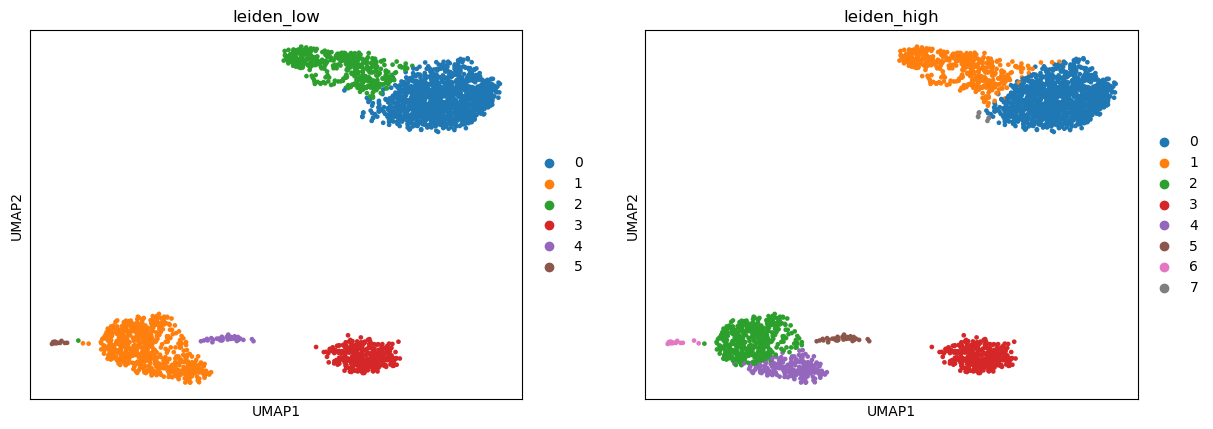

In [111]:
# import numpy as np
# adata = sc.read_10x_mtx(
#     './data/filtered_gene_bc_matrices/hg19/',  # the directory with the `.mtx` file
#     var_names='gene_symbols',                  # use gene symbols for the variable names (variables-axis index)
#     cache=True)   

# adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`
# sc.pp.filter_cells(adata, min_genes=200)
# sc.pp.filter_genes(adata, min_cells=3)
# mito_genes = adata.var_names.str.startswith('MT-')
# # for each cell compute fraction of counts in mito genes vs. all genes
# # the `.A1` is only necessary as X is sparse (to transform to a dense array after summing)
# adata.obs['percent_mito'] = np.sum(
#     adata[:, mito_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1
# # add the total counts per cell as observations-annotation to adata
# adata.obs['n_counts'] = adata.X.sum(axis=1)
# adata = adata[adata.obs.n_genes < 2500, :]
# adata = adata[adata.obs.percent_mito < 0.05, :]
# sc.pp.normalize_total(adata, target_sum=1e4)
# adata_norm = adata.copy()
# sc.pp.log1p(adata)
# adata.raw = adata
# sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
# adata = adata[:, adata.var.highly_variable]
# sc.pp.scale(adata, max_value=10)
# sc.tl.pca(adata, svd_solver='arpack')
# sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
# sc.tl.umap(adata)
sc.tl.leiden(adata, key_added='leiden_low', resolution=.5)
sc.tl.leiden(adata, key_added='leiden_high', resolution=1)
sc.pl.umap(adata, color=['leiden_low', 'leiden_high'])

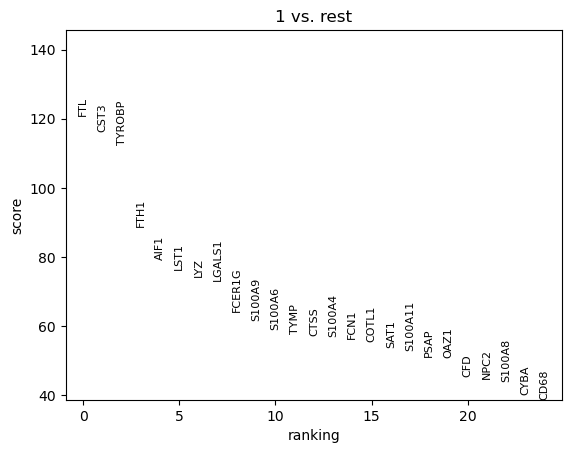

In [115]:
sc.tl.rank_genes_groups(adata, 'leiden_low', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, groups=['1'])

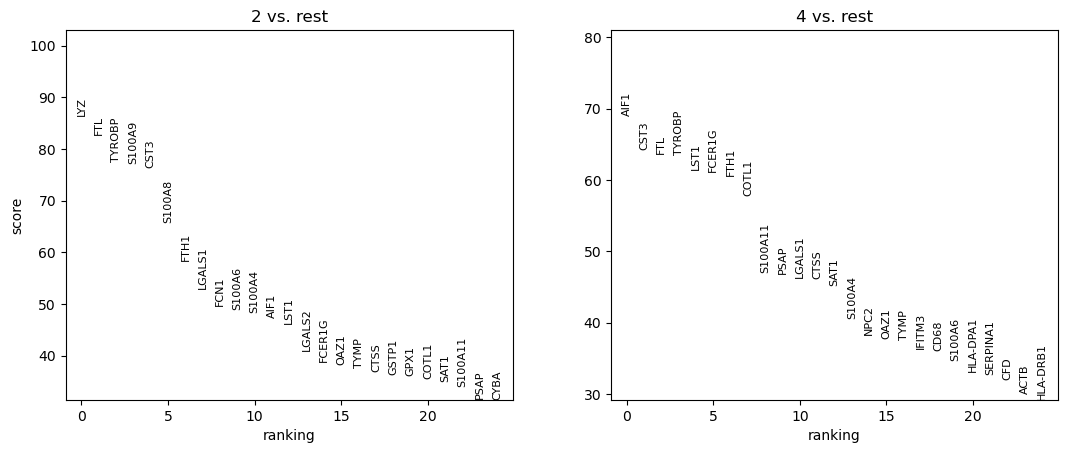

In [117]:
sc.tl.rank_genes_groups(adata, 'leiden_high', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, groups=['2', '4'])

In [ ]:
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_low", groups=["2"],)
sc.pl.rank_genes_groups(adata_norm, n_genes=25, sharey=False, groups=['2', '4'])

## Multi-condition PBMCs

In [ ]:
# adata = sc.read(
#     "kang_counts_25k.h5ad", backup_url="https://figshare.com/ndownloader/files/34464122"
# )
# adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [4]:
# Storing the counts for later use
adata.X = adata.X.toarray()
# Renaming label to condition
adata.obs = adata.obs.rename({"label": "condition"}, axis=1)
adata.obs["group"] = adata.obs.condition.astype("string") + "_" + adata.obs.cell_type.astype("string")

# Normalizing
sc.pp.normalize_total(adata)
adata_norm = adata.copy()
sc.pp.log1p(adata)

In [5]:
adata.obs["group"].value_counts()

group
stim_CD4 T cells          5678
ctrl_CD4 T cells          5560
ctrl_CD14+ Monocytes      2932
stim_CD14+ Monocytes      2765
stim_B cells              1335
ctrl_B cells              1316
stim_NK cells              861
ctrl_NK cells              855
ctrl_CD8 T cells           811
stim_CD8 T cells           810
stim_FCGR3A+ Monocytes     569
ctrl_FCGR3A+ Monocytes     520
stim_Dendritic cells       271
ctrl_Dendritic cells       258
stim_Megakaryocytes         69
ctrl_Megakaryocytes         63
Name: count, dtype: Int64

In [6]:
# Take one condition
adata = adata[adata.obs['condition'] == 'ctrl']
adata.obs['condition'].value_counts()

condition
ctrl    12315
Name: count, dtype: int64

/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_1905/2362789765.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=.2, key_added="leiden_1")


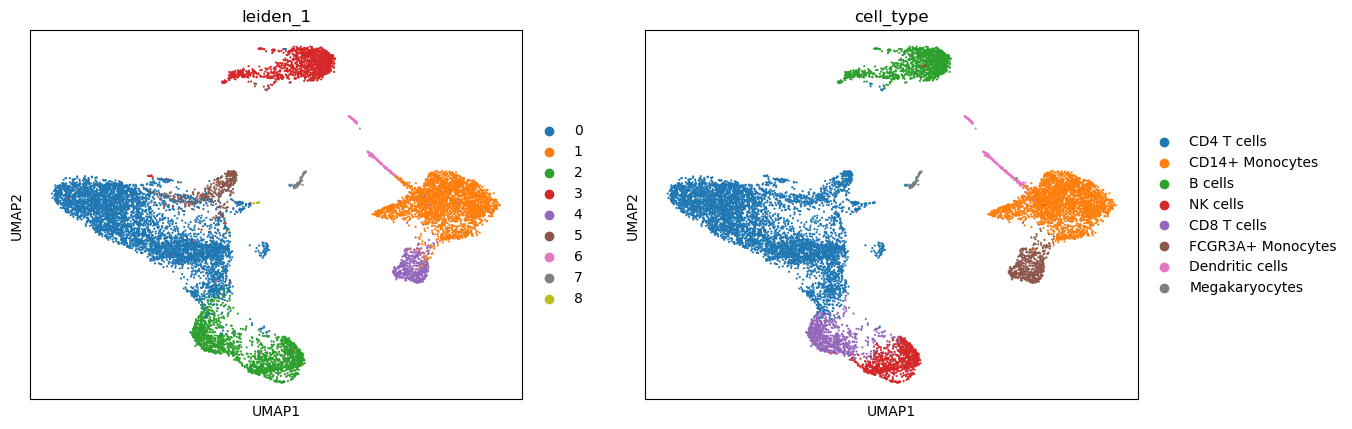

In [ ]:
# # # Cluster
# sc.pp.pca(adata, n_comps=50)
# sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca")
sc.tl.leiden(adata, resolution=.2, key_added="leiden_1")
sc.pl.umap(adata, color=['leiden_1', 'cell_type'])

In [96]:
adata.obs['cell_subtype'] = adata.obs['cell_type']
adata.obs['cell_type'] = adata.obs['cell_type'].str.replace('CD14+ Monocytes', 'Monocyte')
adata.obs['cell_type'] = adata.obs['cell_type'].str.replace('FCGR3A+ Monocytes', 'Monocyte')

In [100]:
sc.tl.rank_genes_groups(adata, "cell_subtype", method="t-test", corr_method="bonferroni")
df = sc.get.rank_genes_groups_df(adata, group="CD14+ Monocytes")
df.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,FTL,235.892365,4.895079,0.0,0.0
1,TIMP1,167.817657,5.226165,0.0,0.0
2,TYROBP,159.154160,4.404270,0.0,0.0
3,FTH1,153.560410,2.997389,0.0,0.0
4,CD63,138.570023,3.906105,0.0,0.0
5,FCER1G,135.550690,4.302989,0.0,0.0
6,C15orf48,133.403763,5.433740,0.0,0.0
7,S100A11,131.097183,3.033801,0.0,0.0
8,LGALS1,117.955009,3.926145,0.0,0.0
9,S100A10,117.444496,3.149975,0.0,0.0


In [101]:
df = sc.get.rank_genes_groups_df(adata, group="FCGR3A+ Monocytes")
df.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,FTH1,105.813164,2.467747,0.000000e+00,0.000000e+00
1,TIMP1,75.526169,3.920680,0.000000e+00,0.000000e+00
2,S100A11,68.348282,2.310052,0.000000e+00,0.000000e+00
3,FCER1G,66.835754,2.980069,2.301071e-302,3.614063e-298
4,TYROBP,62.880787,2.598882,7.515200e-302,1.180337e-297
5,FCGR3A,57.926964,4.835651,3.201849e-232,5.028824e-228
6,SOD2,56.357700,3.198571,1.764896e-246,2.771945e-242
7,ACTB,53.176952,1.889967,1.757971e-251,2.761069e-247
8,MS4A7,50.438099,4.748713,1.740451e-204,2.733553e-200
9,FTL,44.467010,2.325218,3.900367e-216,6.125916e-212


In [99]:
# sc.tl.rank_genes_groups(adata, "cell_type", method="t-test", corr_method="bonferroni")
df = sc.get.rank_genes_groups_df(adata, group="Monocyte")
df.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,FTL,230.456100,4.937229,0.0,0.0
1,TIMP1,217.148468,6.245297,0.0,0.0
2,TYROBP,193.605759,5.244778,0.0,0.0
3,FTH1,175.083923,3.196877,0.0,0.0
4,FCER1G,172.241989,5.413238,0.0,0.0
5,S100A11,157.491455,3.384399,0.0,0.0
6,C15orf48,129.352341,6.186726,0.0,0.0
7,SOD2,120.232422,5.382462,0.0,0.0
8,CD63,119.298111,3.918661,0.0,0.0
9,TYMP,115.585205,4.580067,0.0,0.0


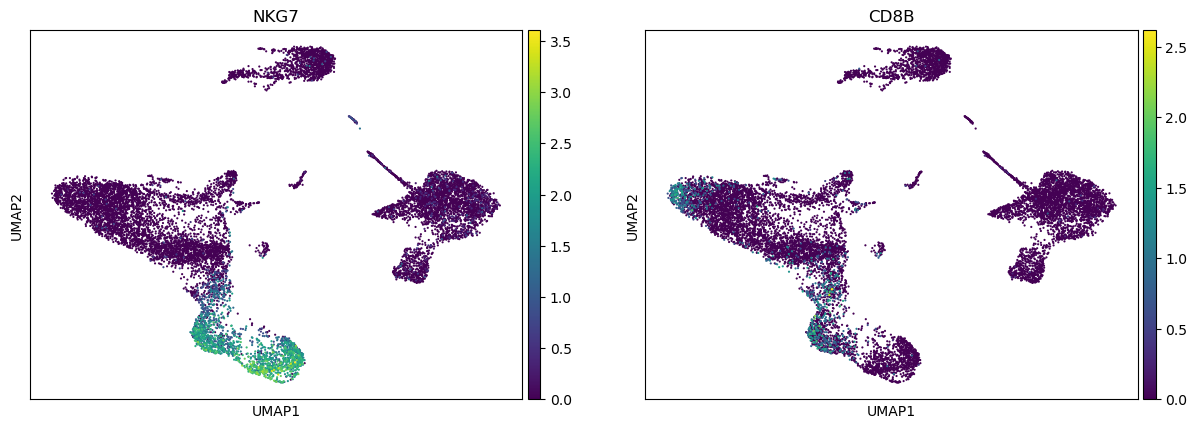

In [95]:
sc.pl.umap(adata, color=['NKG7', 'CD8B'])

In [38]:
sc.tl.rank_genes_groups(adata, "leiden_1", method="t-test",corr_method="bonferroni")

In [41]:
df_1 = sc.get.rank_genes_groups_df(adata, group="2")

In [42]:
df_1.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NKG7,92.673439,6.936393,0.0,0.0
1,B2M,72.656319,0.821251,0.0,0.0
2,CCL5,70.632401,5.733384,0.0,0.0
3,GZMB,65.043587,7.522554,0.0,0.0
4,TMSB4X,60.602932,0.982777,0.0,0.0
5,GNLY,60.448631,7.883568,0.0,0.0
6,HLA-A,59.211483,1.370384,0.0,0.0
7,HLA-B,57.454601,1.106363,0.0,0.0
8,APOBEC3G,54.658722,4.354629,0.0,0.0
9,CST7,48.872398,4.980371,0.0,0.0


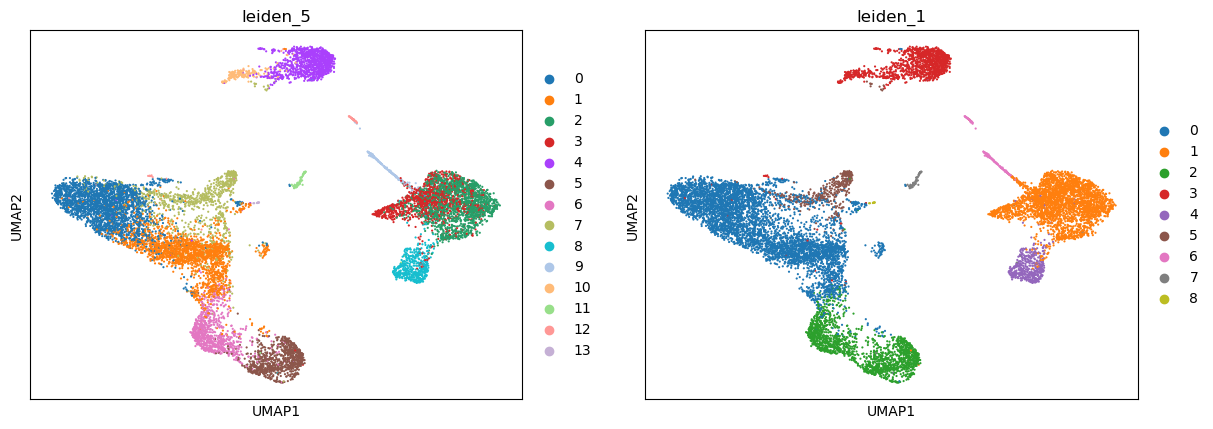

In [18]:
sc.tl.leiden(adata, resolution=1., key_added="leiden_5")
sc.pl.umap(adata, color=['leiden_5', 'leiden_1'])

In [90]:
df_ln_2_5.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,B2M,53.915306,0.746993,0.0,0.0
1,CCL5,53.659992,3.524244,0.0,0.0
2,GZMH,46.537849,4.939888,0.0,0.0
3,APOBEC3G,43.872387,2.847388,0.0,0.0
4,NKG7,43.361416,2.818237,0.0,0.0
5,TMSB4X,41.267570,0.697225,0.0,0.0
6,CST7,38.136696,2.858618,0.0,0.0
7,HLA-A,36.997066,0.954147,0.0,0.0
8,GZMB,36.705215,2.930504,0.0,0.0
9,CD3D,35.508091,1.809175,0.0,0.0


In [92]:
df_2_5.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CCL5,73.518753,4.999038,0.000000e+00,0.000000e+00
1,B2M,56.009148,0.807703,0.000000e+00,0.000000e+00
2,NKG7,50.596592,4.035298,5.655264e-271,8.882157e-267
3,TMSB4X,46.661934,0.922610,3.074317e-296,4.828522e-292
4,HLA-B,37.620266,0.909822,1.456027e-200,2.286836e-196
5,HLA-A,36.934902,1.122723,2.729187e-194,4.286461e-190
6,GZMB,36.040112,3.994484,3.016622e-177,4.737907e-173
7,APOBEC3G,34.632679,3.281447,3.738758e-168,5.872093e-164
8,GZMH,32.415550,5.298544,7.412020e-152,1.164132e-147
9,CST7,31.003281,3.421860,2.690724e-144,4.226051e-140


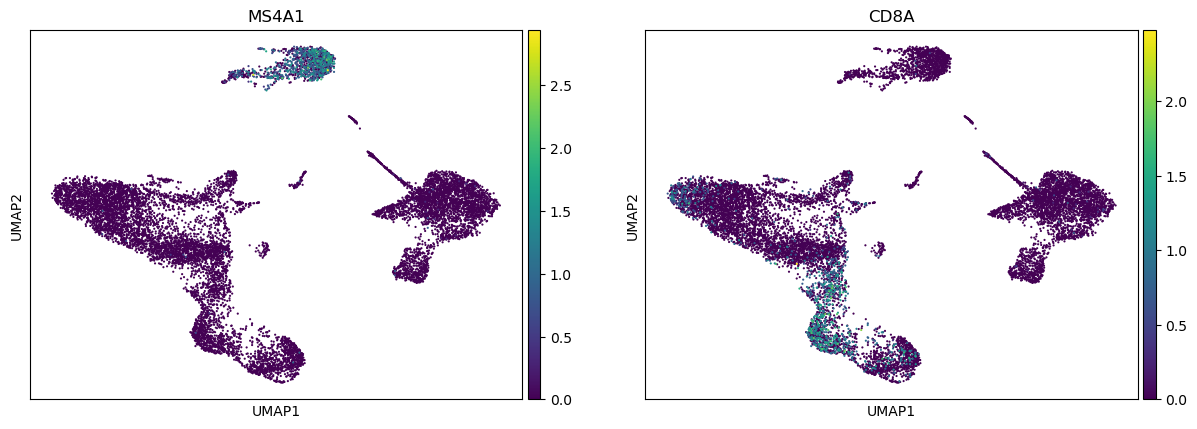

In [87]:
sc.pl.umap(adata, color=['MS4A1', 'CD8A'])

In [20]:
sc.tl.rank_genes_groups(adata, "leiden_5", method="t-test",corr_method="bonferroni")

In [21]:
df_2_4 = sc.get.rank_genes_groups_df(adata, group="5",)
df_2_5 = sc.get.rank_genes_groups_df(adata, group="6")

In [24]:
df_2_4.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,GNLY,80.363541,6.990197,0.000000e+00,0.000000e+00
1,NKG7,72.936615,5.211212,0.000000e+00,0.000000e+00
2,GZMB,48.380676,5.079954,5.625676e-254,8.835686e-250
3,B2M,47.860645,0.710904,1.102998e-284,1.732368e-280
4,HLA-A,45.966400,1.397651,7.547050e-258,1.185340e-253
5,TMSB4X,43.909603,0.899174,2.305000e-271,3.620233e-267
6,HLA-B,41.418713,1.113729,2.305773e-224,3.621447e-220
7,APOBEC3G,36.566483,3.490870,1.487407e-181,2.336122e-177
8,CST7,33.512699,3.881155,5.633897e-161,8.848599e-157
9,CCL5,33.307178,3.799903,1.706518e-160,2.680256e-156


In [25]:
df_2_5.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CCL5,73.518753,4.999038,0.000000e+00,0.000000e+00
1,B2M,56.009148,0.807703,0.000000e+00,0.000000e+00
2,NKG7,50.596592,4.035298,5.655264e-271,8.882157e-267
3,TMSB4X,46.661934,0.922610,3.074317e-296,4.828522e-292
4,HLA-B,37.620266,0.909822,1.456027e-200,2.286836e-196
5,HLA-A,36.934902,1.122723,2.729187e-194,4.286461e-190
6,GZMB,36.040112,3.994484,3.016622e-177,4.737907e-173
7,APOBEC3G,34.632679,3.281447,3.738758e-168,5.872093e-164
8,GZMH,32.415550,5.298544,7.412020e-152,1.164132e-147
9,CST7,31.003281,3.421860,2.690724e-144,4.226051e-140


In [ ]:
# Compare children with parent
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_2_4 and df_1
genes_common = set(df_2_4["names"]) & set(df_1["names"])
genes_common = list(genes_common)

# Get the rank of each gene (1 = highest score)
ranks_2_4 = df_2_4.set_index("names").loc[genes_common, "scores"].rank(ascending=False)
ranks_1 = df_1.set_index("names").loc[genes_common, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr, spearman_p = spearmanr(ranks_2_4, ranks_1)
kendall_corr, kendall_p = kendalltau(ranks_2_4, ranks_1)

print(f"Spearman rank correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")
print(f"Kendall tau correlation: {kendall_corr:.4f}, p-value: {kendall_p:.4e}")


Spearman rank correlation: 0.3179, p-value: 0.0000e+00
Kendall tau correlation: 0.2281, p-value: 0.0000e+00


In [ ]:
# Compare children with parent
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_2_5 and df_1
genes_common = set(df_2_5["names"]) & set(df_1["names"])
genes_common = list(genes_common)

# Get the rank of each gene (1 = highest score)
ranks_2_5 = df_2_5.set_index("names").loc[genes_common, "scores"].rank(ascending=False)
ranks_1 = df_1.set_index("names").loc[genes_common, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr, spearman_p = spearmanr(ranks_2_5, ranks_1)
kendall_corr, kendall_p = kendalltau(ranks_2_5, ranks_1)

print(f"Spearman rank correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")
print(f"Kendall tau correlation: {kendall_corr:.4f}, p-value: {kendall_p:.4e}")


Spearman rank correlation: 0.7837, p-value: 0.0000e+00
Kendall tau correlation: 0.6248, p-value: 0.0000e+00


### LN

In [28]:
adata_norm = adata_norm[adata.obs.index]
adata_norm.obs = adata.obs.copy()

In [29]:
import importlib
import os

file_path = os.path.join(os.getcwd(), "../../pkg/", "scanpy_wrapper.py")
spec = importlib.util.spec_from_file_location("scanpy_wrapper", file_path)
scanpy_wrapper = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scanpy_wrapper)

# LN's t-test uses normalized data without log1p
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_1", groups=["2"],)
df_ln_1 = sc.get.rank_genes_groups_df(adata_norm, group="2")
df_ln_1


Processing group: 2


,names,scores,logfoldchanges,pvals,pvals_adj
0,B2M,73.523933,0.774719,0.0,0.0
1,NKG7,69.270103,6.517502,0.0,0.0
2,APOBEC3G,69.174652,4.189100,0.0,0.0
3,CCL5,64.120193,5.140039,0.0,0.0
4,HLA-A,62.492840,1.254911,0.0,0.0
...,...,...,...,...,...
15701,S100A11,-33.693462,-2.061322,0.0,0.0
15702,PABPC1,-37.048885,-1.781041,0.0,0.0
15703,TIMP1,-50.083347,-4.373459,0.0,0.0
15704,FTH1,-53.865242,-2.143798,0.0,0.0


In [30]:
# LN's t-test uses normalized data without log1p
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_5", groups=["5", "6"])
df_ln_2_4 = sc.get.rank_genes_groups_df(adata_norm, group="5")
df_ln_2_5 = sc.get.rank_genes_groups_df(adata_norm, group="6")

Processing group: 5
Processing group: 6


In [31]:
df_ln_2_4

,names,scores,logfoldchanges,pvals,pvals_adj
0,NKG7,67.555183,4.242091,0.0,0.0
1,GNLY,66.318443,5.833978,0.0,0.0
2,GZMB,52.579853,4.171852,0.0,0.0
3,APOBEC3G,49.402451,3.113317,0.0,0.0
4,HLA-A,48.138641,1.261300,0.0,0.0
...,...,...,...,...,...
15701,RPS18,-24.008980,-0.838294,0.0,0.0
15702,PABPC1,-24.289309,-1.731980,0.0,0.0
15703,FTH1,-35.437271,-1.905005,0.0,0.0
15704,TIMP1,-36.449627,-3.985170,0.0,0.0


In [32]:
df_ln_2_5

,names,scores,logfoldchanges,pvals,pvals_adj
0,B2M,53.915306,0.746993,0.0,0.0
1,CCL5,53.659992,3.524244,0.0,0.0
2,GZMH,46.537849,4.939888,0.0,0.0
3,APOBEC3G,43.872387,2.847388,0.0,0.0
4,NKG7,43.361416,2.818237,0.0,0.0
...,...,...,...,...,...
15701,S100A11,-22.810457,-1.819688,0.0,0.0
15702,PABPC1,-27.347723,-1.642405,0.0,0.0
15703,TIMP1,-34.360394,-4.680542,0.0,0.0
15704,FTH1,-41.273365,-2.185053,0.0,0.0


In [62]:
# Compare children with parent using LN results
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_ln_2_4 and df_ln_1
genes_common_ln = set(df_ln_2_4["names"]) & set(df_ln_1["names"])
genes_common_ln = list(genes_common_ln)

# Get the rank of each gene (1 = highest score)
ranks_2_4_ln = df_ln_2_4.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)
ranks_1_ln = df_ln_1.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr_ln, spearman_p_ln = spearmanr(ranks_2_4_ln, ranks_1_ln)
kendall_corr_ln, kendall_p_ln = kendalltau(ranks_2_4_ln, ranks_1_ln)

print(f"Spearman rank correlation (LN): {spearman_corr_ln:.4f}, p-value: {spearman_p_ln:.4e}")
print(f"Kendall tau correlation (LN): {kendall_corr_ln:.4f}, p-value: {kendall_p_ln:.4e}")


Spearman rank correlation (LN): 0.3025, p-value: 0.0000e+00
Kendall tau correlation (LN): 0.2164, p-value: 0.0000e+00


In [35]:
# Weighted Jaccard over prefixes between the top 100 genes in df_1 and df_2_4

def weighted_jaccard_prefix(A, B, max_prefix=100):
    """
    Compute the weighted Jaccard over all prefixes between two lists.
    For each prefix k (1...max_prefix), compute Jaccard of top-k of A and B, weighted by k (or uniform).
    Returns: weighted Jaccard index (float)
    """
    total = 0.0
    weight_sum = 0.0
    set_A = set()
    set_B = set()
    for k in range(1, max_prefix+1):
        set_A.add(A[k-1])
        set_B.add(B[k-1])
        jaccard = len(set_A & set_B) / len(set_A | set_B)
        weight = 1/k # can make weight=k or weight=1; here uniform
        total += weight * jaccard
        weight_sum += weight
    return total / weight_sum

topA = df_1.sort_values("scores", ascending=False).head(1136)["names"].tolist()
topB = df_2_4.sort_values("scores", ascending=False).head(1136)["names"].tolist()
wjac = weighted_jaccard_prefix(topA, topB, max_prefix=1136)
print(f"Weighted Jaccard over prefixes (top 100): {wjac:.4f}")

topA = df_ln_1.sort_values("scores", ascending=False).head(1136)["names"].tolist()
topB = df_ln_2_4.sort_values("scores", ascending=False).head(1136)["names"].tolist()
wjac = weighted_jaccard_prefix(topA, topB, max_prefix=1136)
print(f"Weighted Jaccard over prefixes (top 100): {wjac:.4f}")


Weighted Jaccard over prefixes (top 100): 0.5604
Weighted Jaccard over prefixes (top 100): 0.4789


In [34]:
topB

['NKG7',
 'GNLY',
 'GZMB',
 'APOBEC3G',
 'HLA-A',
 'CST7',
 'CLIC3',
 'B2M',
 'HLA-B',
 'CCL5',
 'TMSB4X',
 'CTSW',
 'FGFBP2',
 'PRF1',
 'CHST12',
 'HLA-C',
 'APMAP',
 'TNFRSF18',
 'CD7',
 'GZMA',
 'KLRD1',
 'CD247',
 'RARRES3',
 'HOPX',
 'IGFBP7',
 'LDHA',
 'SPON2',
 'AOAH',
 'MATK',
 'GCHFR',
 'C1orf21',
 'KLRC1',
 'CD300A',
 'CLEC2B',
 'FEZ1',
 'SH2D2A',
 'C5orf56',
 'FASLG',
 'S1PR5',
 'LINC00996',
 'KLRB1',
 'LAT2',
 'CXCR3',
 'SLA2',
 'RAMP1',
 'C9orf142',
 'SH2D1B',
 'PTMA',
 'DHRS7',
 'EVL',
 'MIR142',
 'GZMH',
 'LY6E',
 'SEPT7',
 'TMIGD2',
 'IL2RB',
 'IFITM2',
 'CYBA',
 'CD38',
 'PRDX5',
 'GZMM',
 'EIF4EBP1',
 'KLRF1',
 'PYHIN1',
 'CEBPD',
 'GNPTAB',
 'GNG2',
 'UBB',
 'C12orf75',
 'HMGN3',
 'PLAC8',
 'ID2',
 'SRGN',
 'IL2RG',
 'RP11-426C22.5',
 'DUSP2',
 'PLEKHF1',
 'MALAT1',
 'LIMD2',
 'OSTF1',
 'HMGB1',
 'PSMB9',
 'HCST',
 'PDIA3',
 'AKR1C3',
 'ALOX5AP',
 'PRR5L',
 'SLC9A3R1',
 'YPEL1',
 'ABI3',
 'SLC15A4',
 'DUSP10',
 'DRAP1',
 'SYNGR1',
 'CD244',
 'IER2',
 'LAIR2',
 'CD96'

In [23]:
# Compare children with parent using LN results
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_ln_2_5 and df_ln_1
genes_common_ln = set(df_ln_2_5["names"]) & set(df_ln_1["names"])
genes_common_ln = list(genes_common_ln)

# Get the rank of each gene (1 = highest score)
ranks_2_5_ln = df_ln_2_5.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)
ranks_1_ln = df_ln_1.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr_ln, spearman_p_ln = spearmanr(ranks_2_5_ln, ranks_1_ln)
kendall_corr_ln, kendall_p_ln = kendalltau(ranks_2_5_ln, ranks_1_ln)

print(f"Spearman rank correlation (LN): {spearman_corr_ln:.4f}, p-value: {spearman_p_ln:.4e}")
print(f"Kendall tau correlation (LN): {kendall_corr_ln:.4f}, p-value: {kendall_p_ln:.4e}")


Spearman rank correlation (LN): 0.7589, p-value: 0.0000e+00
Kendall tau correlation (LN): 0.5962, p-value: 0.0000e+00


In [43]:
df_1.loc[df_1["pvals_adj"] < 0.05].shape[0], df_ln_1.loc[df_ln_1["pvals_adj"] < 0.05].shape[0]

(1897, 1516)

In [44]:
df_2_4.loc[df_2_4["pvals_adj"] < 0.05].shape[0], df_ln_2_4.loc[df_ln_2_4["pvals_adj"] < 0.05].shape[0]

(1728, 1124)

In [45]:
df_2_5.loc[df_2_5["pvals_adj"] < 0.05].shape[0], df_ln_2_5.loc[df_ln_2_5["pvals_adj"] < 0.05].shape[0]

(1795, 725)

In [47]:
log1p_rnk

,names,scores,logfoldchanges,pvals,pvals_adj
0,NKG7,92.673439,6.936393,0.0,0.0
1,B2M,72.656319,0.821251,0.0,0.0
2,CCL5,70.632401,5.733384,0.0,0.0
3,GZMB,65.043587,7.522554,0.0,0.0
4,TMSB4X,60.602932,0.982777,0.0,0.0
...,...,...,...,...,...
15701,SPI1,-55.088047,-5.847009,0.0,0.0
15702,C15orf48,-55.436871,-4.286778,0.0,0.0
15703,SOD2,-58.903790,-4.283747,0.0,0.0
15704,CCR7,-60.745434,-3.886472,0.0,0.0


In [ ]:
sc.tl.rank_genes_groups(adata, "leiden_1", method="t-test",corr_method="bonferroni")
log1p_rnk = sc.get.rank_genes_groups_df(adata, "2")
log1p_gsea = gp.prerank(rnk=log1p_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
log1p_gsea.res2d[log1p_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val").sort_values("ES", ascending=False)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
3,prerank,Natural killer cell mediated cytotoxicity Homo...,0.579067,2.080748,0.0,0.042691,0.043,31/104,3.94%,GZMB;HLA-A;HLA-B;HLA-C;KLRD1;PRF1;CD247;FASLG;...
31,prerank,Proteoglycans in cancer Homo sapiens hsa05205,-0.565283,-1.660809,0.0,0.045586,0.63,33/153,8.98%,PLAUR;CTSL;ACTB;HPSE;THBS1;TLR2;MYC;RAC1;GRB2;...
28,prerank,Transcriptional misregulation in cancer Homo s...,-0.565449,-1.666499,0.0,0.04532,0.607,30/139,7.33%,CCR7;SPI1;CD14;CD86;DUSP6;MYC;LYL1;CSF1R;CEBPB...
24,prerank,Cytokine-cytokine receptor interaction Homo sa...,-0.572558,-1.708172,0.0,0.026377,0.418,64/186,10.32%,CCR7;LTB;IFNGR2;CXCL16;CCL2;IL1B;CXCL3;IL13RA1...
21,prerank,Lysosome Homo sapiens hsa04142,-0.59962,-1.737049,0.0,0.018539,0.28,27/115,7.98%,CTSL;NPC2;CTSB;CD68;PSAP;CTSH;LGMN;CTSS;ATP6V0...
27,prerank,NF-kappa B signaling pathway Homo sapiens hsa0...,-0.602088,-1.674692,0.0,0.042465,0.572,25/87,8.61%,LTB;CD14;IL1B;CXCL2;TNFSF13B;BTK;CD40;BLNK;TLR...
32,prerank,Adherens junction Homo sapiens hsa04520,-0.603396,-1.654563,0.001218,0.047825,0.656,21/65,13.36%,LEF1;ACTB;RAC1;PVRL2;ACTN1;PTPN6;CTNNA1;ACTG1;...
17,prerank,Phagosome Homo sapiens hsa04145,-0.637362,-1.843585,0.0,0.002916,0.046,47/124,7.25%,HLA-DRA;CD14;CTSL;HLA-DRB1;CYBB;NCF2;HLA-DQB1;...
19,prerank,Amoebiasis Homo sapiens hsa05146,-0.64216,-1.760148,0.0,0.014403,0.214,21/68,9.26%,CD14;IL1B;TLR2;HSPB1;GNA15;ACTN1;IL10;IL1R2;CX...
20,prerank,Pertussis Homo sapiens hsa05133,-0.64219,-1.737497,0.001198,0.01926,0.279,24/62,10.11%,CD14;IL1B;FOS;IL10;IL23A;TLR4;ITGAM;SERPING1;G...


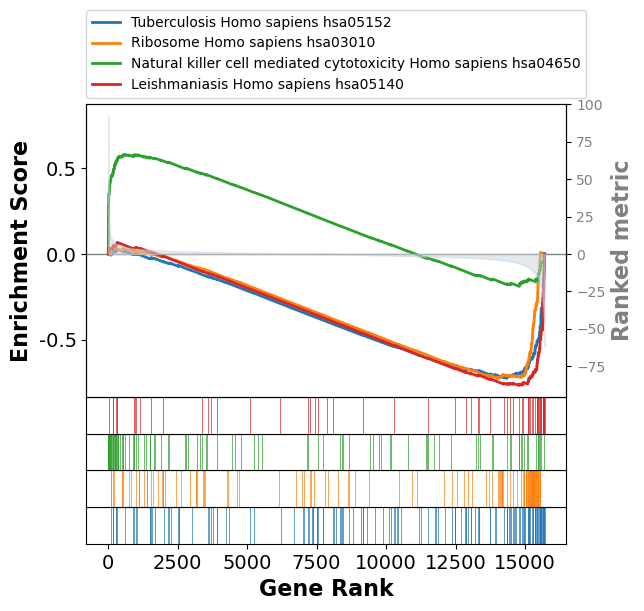

In [52]:
terms = log1p_gsea.res2d.Term
axs = log1p_gsea.plot(
                   terms=terms[1:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

In [57]:
sc.tl.rank_genes_groups(adata, "leiden_5", method="t-test",corr_method="bonferroni")
log1p_rnk = sc.get.rank_genes_groups_df(adata, "5")
log1p_gsea = gp.prerank(rnk=log1p_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
log1p_gsea.res2d[log1p_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val").sort_values("ES", ascending=False)

2026-01-20 09:21:09,215 [WARNING] Duplicated values found in preranked stats: 4.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-20 09:21:09,215 [INFO] Parsing data files for GSEA.............................
2026-01-20 09:21:09,223 [INFO] Enrichr library gene sets already downloaded in: /Users/pedroferreira/.cache/gseapy, use local file
2026-01-20 09:21:09,230 [INFO] 0004 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-20 09:21:09,231 [INFO] 0289 gene_sets used for further statistical testing.....
2026-01-20 09:21:09,231 [INFO] Start to run GSEA...Might take a while..................
2026-01-20 09:21:12,321 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,prerank,Natural killer cell mediated cytotoxicity Homo...,0.611563,2.304666,0.0,0.008668,0.008,32/104,3.81%,GZMB;HLA-A;HLA-B;HLA-C;PRF1;KLRD1;CD247;KLRC1;...
20,prerank,Cytokine-cytokine receptor interaction Homo sa...,-0.592273,-1.743781,0.0,0.015101,0.236,57/186,9.14%,IFNGR2;CCR7;LTB;CXCL16;CCL2;IL1B;CXCL2;CXCL3;I...
23,prerank,Cell adhesion molecules (CAMs) Homo sapiens hs...,-0.607866,-1.689622,0.001074,0.032397,0.442,34/94,7.63%,HLA-DRA;HLA-DRB1;HLA-DQB1;HLA-DQA1;VCAN;CD86;H...
24,prerank,Pertussis Homo sapiens hsa05133,-0.614146,-1.671247,0.005624,0.041098,0.541,27/62,16.08%,CD14;IL1B;IL10;TLR4;FOS;IL23A;ITGAM;SERPING1;L...
22,prerank,Salmonella infection Homo sapiens hsa05132,-0.623398,-1.712756,0.0,0.023319,0.345,25/74,14.05%,CD14;IFNGR2;IL1B;CXCL2;CXCL3;ACTB;TLR4;FOS;ARP...
15,prerank,Phagosome Homo sapiens hsa04145,-0.643885,-1.860045,0.0,0.001906,0.028,39/124,5.41%,HLA-DRA;HLA-DRB1;CD14;CTSL;CYBB;HLA-DQB1;HLA-D...
25,prerank,Malaria Homo sapiens hsa05144,-0.652448,-1.657358,0.003429,0.047156,0.598,22/40,16.06%,CCL2;IL1B;THBS1;SDC2;TLR2;IL10;CD36;TLR4;LRP1;...
12,prerank,Osteoclast differentiation Homo sapiens hsa04380,-0.66666,-1.919566,0.0,0.000493,0.006,45/122,11.21%,SPI1;IFNGR2;CYBB;NCF2;IL1B;LILRA3;LILRB4;SOCS3...
11,prerank,Toxoplasmosis Homo sapiens hsa05145,-0.687369,-1.949085,0.0,0.00009,0.001,36/103,10.31%,HLA-DRA;HLA-DRB1;IFNGR2;HLA-DQB1;HLA-DQA1;HLA-...
8,prerank,Tuberculosis Homo sapiens hsa05152,-0.697552,-2.022613,0.0,0.0,0.0,48/148,9.77%,HLA-DRA;HLA-DRB1;CD14;IFNGR2;HLA-DQB1;HLA-DQA1...


In [58]:
sc.tl.rank_genes_groups(adata, "leiden_5", method="t-test",corr_method="bonferroni")
log1p_rnk = sc.get.rank_genes_groups_df(adata, "6")
log1p_gsea = gp.prerank(rnk=log1p_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
log1p_gsea.res2d[log1p_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val").sort_values("ES", ascending=False)

2026-01-20 09:21:32,734 [WARNING] Duplicated values found in preranked stats: 4.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-20 09:21:32,735 [INFO] Parsing data files for GSEA.............................
2026-01-20 09:21:32,742 [INFO] Enrichr library gene sets already downloaded in: /Users/pedroferreira/.cache/gseapy, use local file
2026-01-20 09:21:32,749 [INFO] 0004 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-20 09:21:32,750 [INFO] 0289 gene_sets used for further statistical testing.....
2026-01-20 09:21:32,750 [INFO] Start to run GSEA...Might take a while..................
2026-01-20 09:21:35,839 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
29,prerank,Cytokine-cytokine receptor interaction Homo sa...,-0.597682,-1.602034,0.0,0.04415,0.652,67/186,11.45%,CCR7;LTB;IFNGR2;CXCL16;CCL2;CXCL3;IL1B;TNFSF13...
26,prerank,Proteoglycans in cancer Homo sapiens hsa05205,-0.611229,-1.627607,0.0,0.033688,0.525,37/153,11.21%,PLAUR;CTSL;HPSE;MYC;ACTB;THBS1;RAC1;CD63;TLR2;...
31,prerank,Hematopoietic cell lineage Homo sapiens hsa04640,-0.626191,-1.599363,0.002068,0.044263,0.66,28/76,7.32%,CD14;HLA-DRA;CD9;IL1B;CD55;MS4A1;ANPEP;CSF1R;H...
20,prerank,Transcriptional misregulation in cancer Homo s...,-0.636411,-1.66997,0.0,0.021636,0.317,45/139,12.64%,CCR7;SPI1;CD14;CD86;MYC;DUSP6;CSF1R;CD40;MEF2C...
32,prerank,Pertussis Homo sapiens hsa05133,-0.637159,-1.589966,0.002099,0.049435,0.705,22/62,12.44%,CD14;IL1B;FOS;IL10;IRF8;TLR4;IL23A;ITGAM;SERPI...
24,prerank,NF-kappa B signaling pathway Homo sapiens hsa0...,-0.638294,-1.639406,0.0,0.029929,0.472,28/87,11.30%,CD14;LTB;IL1B;TNFSF13B;CXCL2;NFKBIA;BTK;CD40;B...
27,prerank,Adherens junction Homo sapiens hsa04520,-0.641981,-1.619936,0.001052,0.036153,0.557,19/65,10.14%,LEF1;ACTB;ACTN1;RAC1;PVRL2;SRC;ACTG1;PTPN6;BAI...
16,prerank,Phagosome Homo sapiens hsa04145,-0.645043,-1.709731,0.0,0.012414,0.177,44/124,8.04%,CD14;HLA-DRA;CTSL;NCF2;CYBB;OLR1;HLA-DQA1;FCGR...
19,prerank,Lysosome Homo sapiens hsa04142,-0.645824,-1.684044,0.0,0.01773,0.259,25/115,6.74%,CTSL;CD68;NPC2;CTSB;LGMN;ACP5;PSAP;CD63;CTSH;C...
34,prerank,PPAR signaling pathway Homo sapiens hsa03320,-0.656372,-1.587232,0.004353,0.047857,0.714,8/44,6.65%,OLR1;GK;CD36;CYP27A1;RXRA;PPARG;ACSL1;FABP5


In [66]:
df_2_4.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,GNLY,80.363541,6.990197,0.000000e+00,0.000000e+00
1,NKG7,72.936615,5.211212,0.000000e+00,0.000000e+00
2,GZMB,48.380676,5.079954,5.625676e-254,8.835686e-250
3,B2M,47.860645,0.710904,1.102998e-284,1.732368e-280
4,HLA-A,45.966400,1.397651,7.547050e-258,1.185340e-253
5,TMSB4X,43.909603,0.899174,2.305000e-271,3.620233e-267
6,HLA-B,41.418713,1.113729,2.305773e-224,3.621447e-220
7,APOBEC3G,36.566483,3.490870,1.487407e-181,2.336122e-177
8,CST7,33.512699,3.881155,5.633897e-161,8.848599e-157
9,CCL5,33.307178,3.799903,1.706518e-160,2.680256e-156


In [65]:
df_2_5.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CCL5,73.518753,4.999038,0.000000e+00,0.000000e+00
1,B2M,56.009148,0.807703,0.000000e+00,0.000000e+00
2,NKG7,50.596592,4.035298,5.655264e-271,8.882157e-267
3,TMSB4X,46.661934,0.922610,3.074317e-296,4.828522e-292
4,HLA-B,37.620266,0.909822,1.456027e-200,2.286836e-196
5,HLA-A,36.934902,1.122723,2.729187e-194,4.286461e-190
6,GZMB,36.040112,3.994484,3.016622e-177,4.737907e-173
7,APOBEC3G,34.632679,3.281447,3.738758e-168,5.872093e-164
8,GZMH,32.415550,5.298544,7.412020e-152,1.164132e-147
9,CST7,31.003281,3.421860,2.690724e-144,4.226051e-140


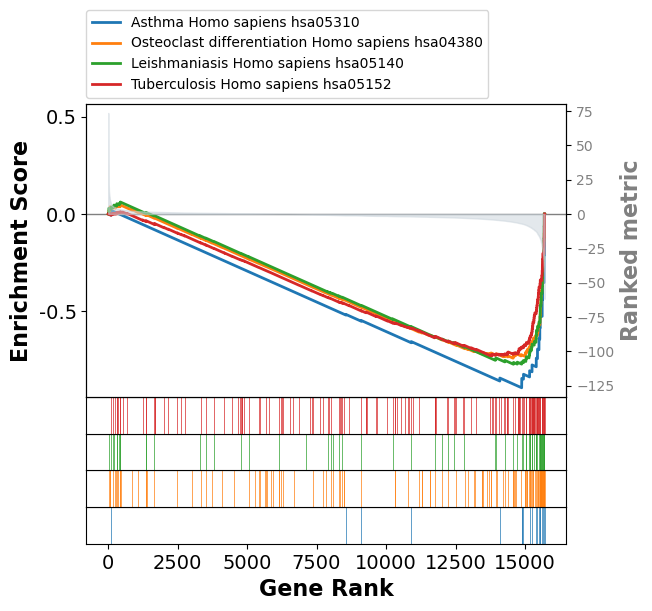

In [59]:
terms = log1p_gsea.res2d.Term
axs = log1p_gsea.plot(
                   terms=terms[1:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

In [81]:
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_1", groups=["2"])
df_ln_1 = sc.get.rank_genes_groups_df(adata_norm, group="2")
ln_rnk = sc.get.rank_genes_groups_df(adata, "2")
ln_gsea = gp.prerank(rnk=ln_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='MSigDB_Hallmark_2020',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
ln_gsea.res2d[ln_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val").sort_values("ES", ascending=False)

Processing group: 2


2026-01-20 09:35:57,540 [WARNING] Duplicated values found in preranked stats: 4.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-20 09:35:57,541 [INFO] Parsing data files for GSEA.............................
2026-01-20 09:35:58,429 [INFO] Downloading and generating Enrichr library gene sets......
2026-01-20 09:35:59,515 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-20 09:35:59,516 [INFO] 0050 gene_sets used for further statistical testing.....
2026-01-20 09:35:59,516 [INFO] Start to run GSEA...Might take a while..................
2026-01-20 09:36:00,319 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
4,prerank,Angiogenesis,0.805094,2.201588,0.0,0.0,0.0,10/22,8.27%,TIMP1;S100A4;VCAN;OLR1;VEGFA;ITGAV;NRP1;THBD;S...
1,prerank,Coagulation,0.665574,2.297891,0.0,0.0,0.0,32/94,7.79%,TIMP1;CTSB;RAC1;OLR1;THBS1;CFD;SERPINA1;DUSP6;...
6,prerank,Reactive Oxygen Species Pathway,0.640254,2.008797,0.0,0.002342,0.003,12/47,2.76%,FTL;SOD2;GPX4;PRDX1;MGST1;TXN;TXNRD1;ATOX1;GLR...
0,prerank,Complement,0.626082,2.342149,0.0,0.0,0.0,63/174,6.79%,FCER1G;TIMP1;ANXA5;LGALS3;PFN1;PLAUR;CTSB;S100...
8,prerank,Cholesterol Homeostasis,0.620793,1.996384,0.0,0.001756,0.003,14/66,4.16%,S100A11;ANXA5;LGALS3;PLAUR;ACTG1;CXCL16;CD9;LG...
5,prerank,Epithelial Mesenchymal Transition,0.614725,2.186657,0.0,0.0,0.0,28/127,6.03%,TIMP1;LGALS1;EMP3;PLAUR;SAT1;VIM;CAPG;TPM4;VCA...
3,prerank,TNF-alpha Signaling via NF-kB,0.588073,2.205164,0.0,0.0,0.0,84/195,8.62%,SOD2;PLAUR;SAT1;KYNU;NFKBIA;CCL2;CEBPB;IER3;NI...
7,prerank,Inflammatory Response,0.544642,2.003232,0.0,0.002007,0.003,59/175,5.83%,TIMP1;EMP3;PLAUR;CD14;NFKBIA;CCL2;CLEC5A;C5AR1...
12,prerank,Protein Secretion,0.512021,1.750277,0.0,0.012176,0.025,31/90,10.42%,CD63;CLTA;GLA;AP2S1;M6PR;COPE;RER1;LAMP2;YKT6;...
17,prerank,TGF-beta Signaling,0.505384,1.573184,0.030612,0.034342,0.098,16/51,10.37%,THBS1;ENG;RHOA;PPP1R15A;IFNGR2;RAB31;PPP1CA;JU...


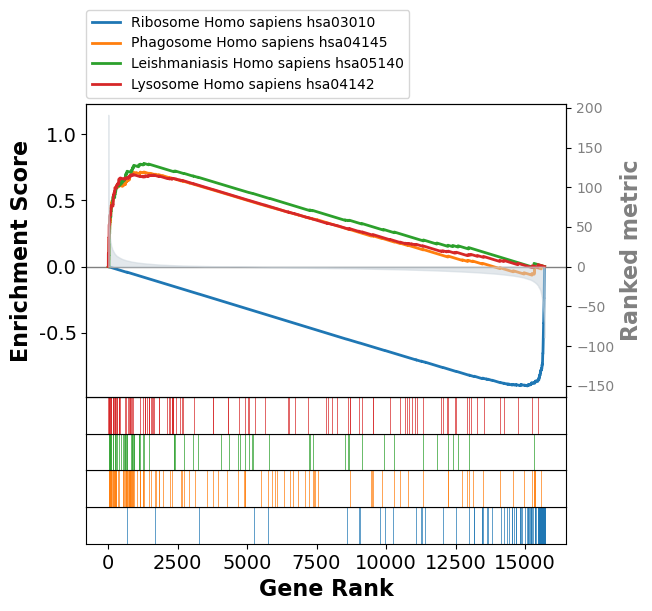

In [77]:
terms = ln_gsea.res2d.Term
axs = ln_gsea.plot(
                   terms=terms[1:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

In [84]:
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_5", groups=["5", "6"])
df_ln_2_4 = sc.get.rank_genes_groups_df(adata_norm, group="5")
df_ln_2_5 = sc.get.rank_genes_groups_df(adata_norm, group="6")
ln_rnk = sc.get.rank_genes_groups_df(adata, "5")
ln_gsea = gp.prerank(rnk=ln_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
ln_gsea.res2d[ln_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val").sort_values("ES", ascending=False)

Processing group: 5
Processing group: 6


2026-01-20 09:37:40,170 [WARNING] Duplicated values found in preranked stats: 4.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-20 09:37:40,170 [INFO] Parsing data files for GSEA.............................
2026-01-20 09:37:40,178 [INFO] Enrichr library gene sets already downloaded in: /Users/pedroferreira/.cache/gseapy, use local file
2026-01-20 09:37:40,186 [INFO] 0004 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-20 09:37:40,187 [INFO] 0289 gene_sets used for further statistical testing.....
2026-01-20 09:37:40,188 [INFO] Start to run GSEA...Might take a while..................
2026-01-20 09:37:43,282 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,prerank,Natural killer cell mediated cytotoxicity Homo...,0.611563,2.304666,0.0,0.008668,0.008,32/104,3.81%,GZMB;HLA-A;HLA-B;HLA-C;PRF1;KLRD1;CD247;KLRC1;...
20,prerank,Cytokine-cytokine receptor interaction Homo sa...,-0.592273,-1.743781,0.0,0.015101,0.236,57/186,9.14%,IFNGR2;CCR7;LTB;CXCL16;CCL2;IL1B;CXCL2;CXCL3;I...
23,prerank,Cell adhesion molecules (CAMs) Homo sapiens hs...,-0.607866,-1.689622,0.001074,0.032397,0.442,34/94,7.63%,HLA-DRA;HLA-DRB1;HLA-DQB1;HLA-DQA1;VCAN;CD86;H...
24,prerank,Pertussis Homo sapiens hsa05133,-0.614146,-1.671247,0.005624,0.041098,0.541,27/62,16.08%,CD14;IL1B;IL10;TLR4;FOS;IL23A;ITGAM;SERPING1;L...
22,prerank,Salmonella infection Homo sapiens hsa05132,-0.623398,-1.712756,0.0,0.023319,0.345,25/74,14.05%,CD14;IFNGR2;IL1B;CXCL2;CXCL3;ACTB;TLR4;FOS;ARP...
15,prerank,Phagosome Homo sapiens hsa04145,-0.643885,-1.860045,0.0,0.001906,0.028,39/124,5.41%,HLA-DRA;HLA-DRB1;CD14;CTSL;CYBB;HLA-DQB1;HLA-D...
25,prerank,Malaria Homo sapiens hsa05144,-0.652448,-1.657358,0.003429,0.047156,0.598,22/40,16.06%,CCL2;IL1B;THBS1;SDC2;TLR2;IL10;CD36;TLR4;LRP1;...
12,prerank,Osteoclast differentiation Homo sapiens hsa04380,-0.66666,-1.919566,0.0,0.000493,0.006,45/122,11.21%,SPI1;IFNGR2;CYBB;NCF2;IL1B;LILRA3;LILRB4;SOCS3...
11,prerank,Toxoplasmosis Homo sapiens hsa05145,-0.687369,-1.949085,0.0,0.00009,0.001,36/103,10.31%,HLA-DRA;HLA-DRB1;IFNGR2;HLA-DQB1;HLA-DQA1;HLA-...
8,prerank,Tuberculosis Homo sapiens hsa05152,-0.697552,-2.022613,0.0,0.0,0.0,48/148,9.77%,HLA-DRA;HLA-DRB1;CD14;IFNGR2;HLA-DQB1;HLA-DQA1...


In [79]:
ln_rnk = sc.get.rank_genes_groups_df(adata, "6")
ln_gsea = gp.prerank(rnk=ln_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
ln_gsea.res2d[ln_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val").sort_values("ES", ascending=False)

2026-01-20 09:34:12,955 [WARNING] Duplicated values found in preranked stats: 4.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-20 09:34:12,956 [INFO] Parsing data files for GSEA.............................
2026-01-20 09:34:12,964 [INFO] Enrichr library gene sets already downloaded in: /Users/pedroferreira/.cache/gseapy, use local file
2026-01-20 09:34:12,971 [INFO] 0004 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-20 09:34:12,972 [INFO] 0289 gene_sets used for further statistical testing.....
2026-01-20 09:34:12,972 [INFO] Start to run GSEA...Might take a while..................
2026-01-20 09:34:16,071 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
29,prerank,Cytokine-cytokine receptor interaction Homo sa...,-0.597682,-1.602034,0.0,0.04415,0.652,67/186,11.45%,CCR7;LTB;IFNGR2;CXCL16;CCL2;CXCL3;IL1B;TNFSF13...
26,prerank,Proteoglycans in cancer Homo sapiens hsa05205,-0.611229,-1.627607,0.0,0.033688,0.525,37/153,11.21%,PLAUR;CTSL;HPSE;MYC;ACTB;THBS1;RAC1;CD63;TLR2;...
31,prerank,Hematopoietic cell lineage Homo sapiens hsa04640,-0.626191,-1.599363,0.002068,0.044263,0.66,28/76,7.32%,CD14;HLA-DRA;CD9;IL1B;CD55;MS4A1;ANPEP;CSF1R;H...
20,prerank,Transcriptional misregulation in cancer Homo s...,-0.636411,-1.66997,0.0,0.021636,0.317,45/139,12.64%,CCR7;SPI1;CD14;CD86;MYC;DUSP6;CSF1R;CD40;MEF2C...
32,prerank,Pertussis Homo sapiens hsa05133,-0.637159,-1.589966,0.002099,0.049435,0.705,22/62,12.44%,CD14;IL1B;FOS;IL10;IRF8;TLR4;IL23A;ITGAM;SERPI...
24,prerank,NF-kappa B signaling pathway Homo sapiens hsa0...,-0.638294,-1.639406,0.0,0.029929,0.472,28/87,11.30%,CD14;LTB;IL1B;TNFSF13B;CXCL2;NFKBIA;BTK;CD40;B...
27,prerank,Adherens junction Homo sapiens hsa04520,-0.641981,-1.619936,0.001052,0.036153,0.557,19/65,10.14%,LEF1;ACTB;ACTN1;RAC1;PVRL2;SRC;ACTG1;PTPN6;BAI...
16,prerank,Phagosome Homo sapiens hsa04145,-0.645043,-1.709731,0.0,0.012414,0.177,44/124,8.04%,CD14;HLA-DRA;CTSL;NCF2;CYBB;OLR1;HLA-DQA1;FCGR...
19,prerank,Lysosome Homo sapiens hsa04142,-0.645824,-1.684044,0.0,0.01773,0.259,25/115,6.74%,CTSL;CD68;NPC2;CTSB;LGMN;ACP5;PSAP;CD63;CTSH;C...
34,prerank,PPAR signaling pathway Homo sapiens hsa03320,-0.656372,-1.587232,0.004353,0.047857,0.714,8/44,6.65%,OLR1;GK;CD36;CYP27A1;RXRA;PPARG;ACSL1;FABP5


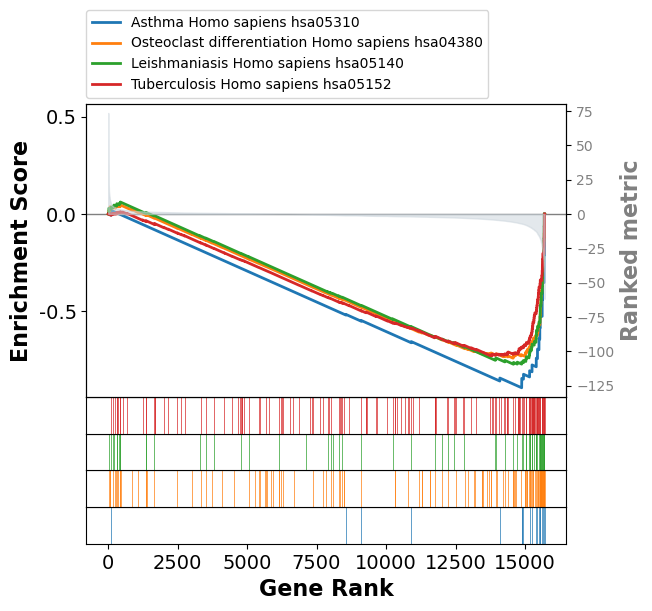

In [80]:
terms = ln_gsea.res2d.Term
axs = ln_gsea.plot(
                   terms=terms[1:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

In [65]:
# Show top 100 genes (by descending score) in df_1 and df_2_4
top = 1000
top100_df_1 = df_1.sort_values("scores", ascending=False).head(top)
top100_df_2_4 = df_2_4.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_1['names'].tolist()).intersection(set(top100_df_2_4['names'].tolist()))))
top100_df_2_5 = df_2_5.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_1['names'].tolist()).intersection(set(top100_df_2_5['names'].tolist()))))


770
668


In [66]:
# Show top 100 genes (by descending score) in df_ln_1 and df_ln_2_4
top100_df_ln_1 = df_ln_1.sort_values("scores", ascending=False).head(top)
top100_df_ln_2_4 = df_ln_2_4.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_ln_1['names'].tolist()).intersection(set(top100_df_ln_2_4['names'].tolist()))))
top100_df_ln_2_5 = df_ln_2_5.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_ln_1['names'].tolist()).intersection(set(top100_df_ln_2_5['names'].tolist()))))


745
641
